In [1]:

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import map_elements as me
from shapely.geometry import Polygon
import numpy as np
import pyproj


custom_laea = '+proj=laea +lat_ts=0 +lat_0=90 +lon_0=-90 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs +type=crs'

## Define bounds
N = 360
AC = 66.33
N60 = 60
lat_point_list = np.ones(N)*AC
lon_point_list = np.linspace(-180,180,N)


bigLine = 5
littleLine = 3
# North of 60 + Arctic Circle
# polygon_geom = Polygon(zip(lon_point_list, lat_point_list))
LatLines = [60,66.33]
geom = [
  Polygon(zip(np.linspace(-180,180,N),np.ones(N)*Lat)) for Lat in LatLines
]
LatLines = gpd.GeoDataFrame(index=LatLines, crs='WGS84', geometry=geom)   
LatLines = LatLines.to_crs(custom_laea)

labelFontSize= 22
lat_point_list = [70.0,70.0,67.5,67.5]
lon_point_list = [-137.0,-132.25,-132.25,-137.0]

polygon_geom = Polygon(zip(lon_point_list, lat_point_list))
deltaBounds = gpd.GeoDataFrame(index=[0], crs='WGS84', geometry=[polygon_geom])   
deltaBounds = deltaBounds.to_crs(custom_laea)

source = 'Data/'
Sites = pd.read_csv(source+'Arctic_EC_Towers.csv')
Sites = gpd.GeoDataFrame(Sites,geometry=gpd.points_from_xy(Sites.Longitude, Sites.Latitude),crs='WGS1984')
Sites = Sites.to_crs(custom_laea)
Sites = Sites.loc[Sites['Latitude']>60.1]
# Sites = gpd.clip(Sites,LatLines.loc[LatLines.index>=60.])

# Sites['End'] = Sites['End'].fillna(2025)
# print(Sites[['CH4','Country','type']].groupby(['CH4','Country']).count())

Sites.loc[((Sites['Country'] == 'Canada')&(Sites['CH4'] == True)),['Site_Name','Site_ID']]


,Site_Name,Site_ID
4,Scotty Creek,CA-SCC
22,Illisarvik,CA-ILL
23,Fish Island,CA-FIL
24,Swiss Cheese Lake,CA-SCL
34,Trail Valley Creek,CA-TVC
48,Havikpak Creek,CA-HPC
64,Daring Lake (mixed tundra),CA-DL1
65,Daring Lake (Fen),CA-DL2
86,Smith Creek,CA-SMC


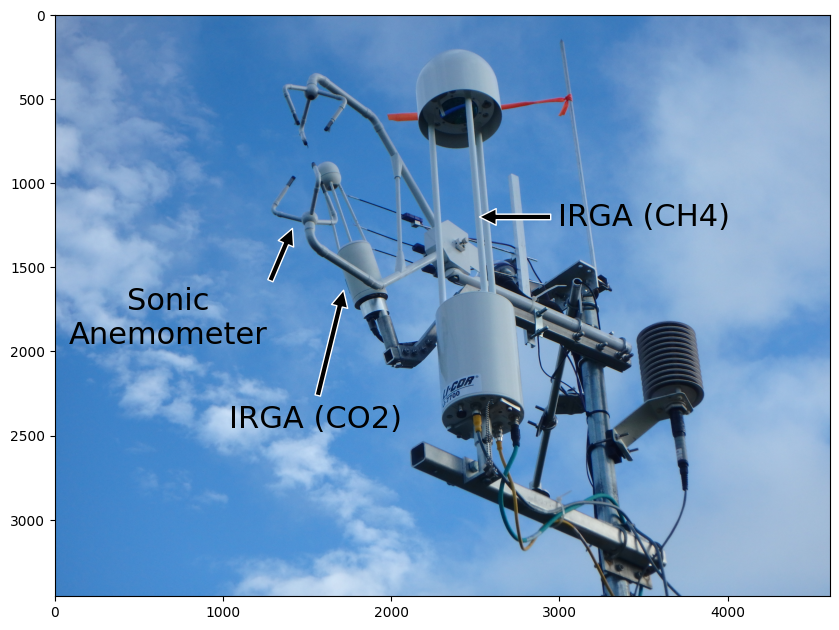

In [ ]:

import matplotlib.patheffects as PathEffects

img = r'images\EC_setup.jpg'
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread(img)
fig,ax=plt.subplots(figsize=(10,10))
imgplot = ax.imshow(img)

arrow = dict(facecolor='black', shrink=0.05,edgecolor='white')


ax.annotate('Sonic\nAnemometer', xy=, xytext=,
            va='center', ha='center',fontsize=22,
            arrowprops=arrow)

ax.annotate('IRGA (CO2)', xy=, xytext=,
            va='center', ha='center',fontsize=22,
            arrowprops=arrow)

for label,xy,xytext in zip(['Sonic\nAnemometer','IRGA (CO2)','IRGA (CH4)'],
                           [(1420,1250),(1725,1600),(2500,1200)],
                           [(675, 1800),(1550, 2400),(3500, 1200)]):
    txt = ax.annotate(label, xy=xy, xytext=xytext,
            va='center', ha='center',fontsize=22,
            arrowprops=arrow)
    txt.set_path_effects([PathEffects.withStroke(linewidth=bubble_width, foreground='white')])


plt.show()

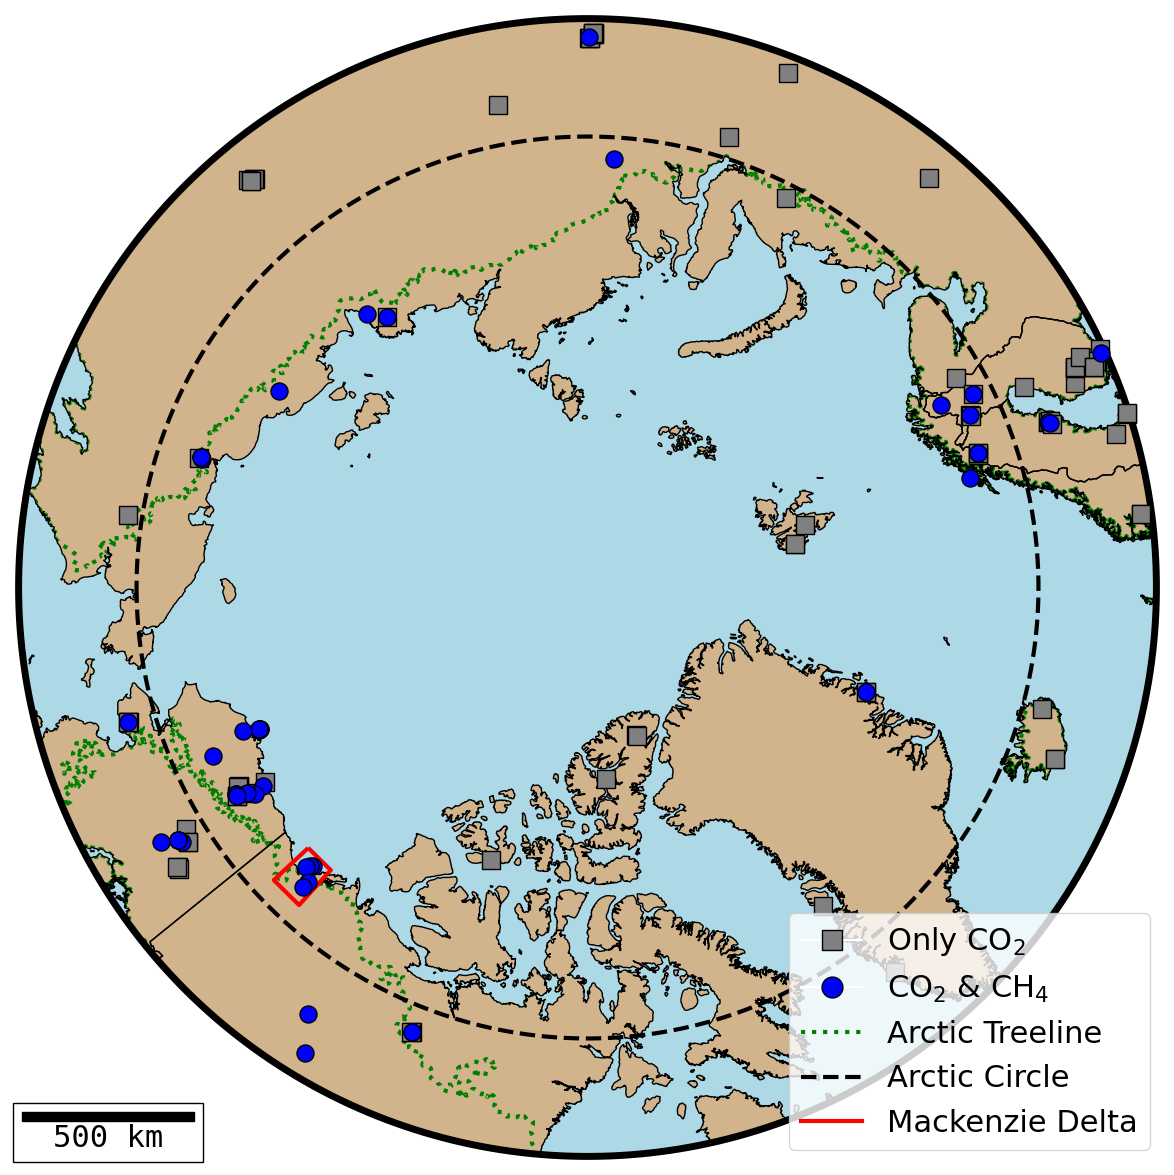

In [3]:


coast = gpd.read_file(source+'cp_coast_la.shp').to_crs(custom_laea)
coast = gpd.clip(coast,LatLines.loc[LatLines.index==60])
Arctic = coast.loc[coast['WATER']<=1].dissolve()
land = coast.loc[coast['COUNTRY']!='wa'].dissolve(by='COUNTRY')
ocean = coast.loc[coast['COUNTRY']=='wa']

fig,ax=plt.subplots(figsize=(15,15))
land.plot(ax=ax,color='tan')
TL_kwargs = {'color':'None',
  'edgecolor':'green',
  'linewidth':littleLine,
  'label':'Arctic Treeline',
  'linestyle':':'}
Arctic.plot(ax=ax,**TL_kwargs)
ocean.plot(ax=ax,color='lightblue')
land.plot(ax=ax,facecolor='None',edgecolor='k')
LatLines.loc[LatLines.index==60].plot(ax=ax,facecolor='None',edgecolor='k',linewidth=bigLine)

AC_kwargs = {
  'color':'None',
  'edgecolor':'k',
  'linestyle':'--',
  'label':'Arctic Circle',
  'linewidth':littleLine
}
LatLines.loc[LatLines.index==66.33].plot(ax=ax,**AC_kwargs)

db_kwargs={
  'color':'None',
  'edgecolor':'red',
  'linewidth':littleLine,
  'label':'Mackenzie Delta'
}

deltaBounds.plot(ax=ax,**db_kwargs)

legend_elements = []


color = 'grey'
label = 'Only CO$_2$'
marker = 's'
MS = 150
kwargs={'color':color,'marker':marker,'markersize':MS,'edgecolor':'k'}
Sites.loc[((Sites['CH4']==False))].plot(ax=ax,**kwargs)
kwargs={'color':'w','markeredgecolor':'k','markerfacecolor':color,'marker':marker,'markersize':MS/10,'label':label}
legend_elements.append(Line2D([0], [0],**kwargs))

label = 'CO$_2$ & CH$_4$'
marker = 'o'
color = 'blue'
kwargs={'color':color,'marker':marker,'markersize':MS,'edgecolor':'k'}
Sites.loc[((Sites['CH4']==True))].plot(ax=ax,**kwargs)

kwargs={'color':'w','markeredgecolor':'k','markerfacecolor':color,'marker':marker,'markersize':MS/10,'label':label}
legend_elements.append(Line2D([0], [0],**kwargs))

TL_kwargs['color'] = 'green'
TL_kwargs.pop('edgecolor')
legend_elements.append(Line2D([0], [0],**TL_kwargs))


AC_kwargs['color'] = 'k'
AC_kwargs.pop('edgecolor')
legend_elements.append(Line2D([0], [0],**AC_kwargs))


db_kwargs['color'] = 'red'
db_kwargs.pop('edgecolor')
legend_elements.append(Line2D([0], [0],**db_kwargs))

ax.legend(handles=legend_elements, loc='lower right',fontsize=labelFontSize,ncol=1)
pad=1e4*bigLine
ax.set_ylim(LatLines.geometry.bounds.miny.min()-pad,LatLines.geometry.bounds.maxy.max()+pad)
ax.set_xlim(LatLines.geometry.bounds.minx.min()-pad,LatLines.geometry.bounds.maxx.max()+pad)
me.scalebar(ax,distance=1e6,pos='lower left',label='500 km',fontsize=labelFontSize)
# plt.title(r'Eddy Covariance Sites North of 60$^{\circ}$')
ax.axis('off')
a=1